## Constructor heuristic examples

`constructor()` is the unified constructive heuristic entry point. The legacy `EW_presolver()` is essentially represented by `constructor()` with `method='biased_EW'` and `weigh_detours=False`.

This notebook compares a few constructor settings on the same location and then converts the topology **S** into routed graphs **G** using `PathFinder`.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import constructor
from optiwindnet.interarraylib import G_from_S, calcload
from optiwindnet.svg import svgplot

In [2]:
locations = load_repository()

## Simple example

Load Hollandse Kust Zuid

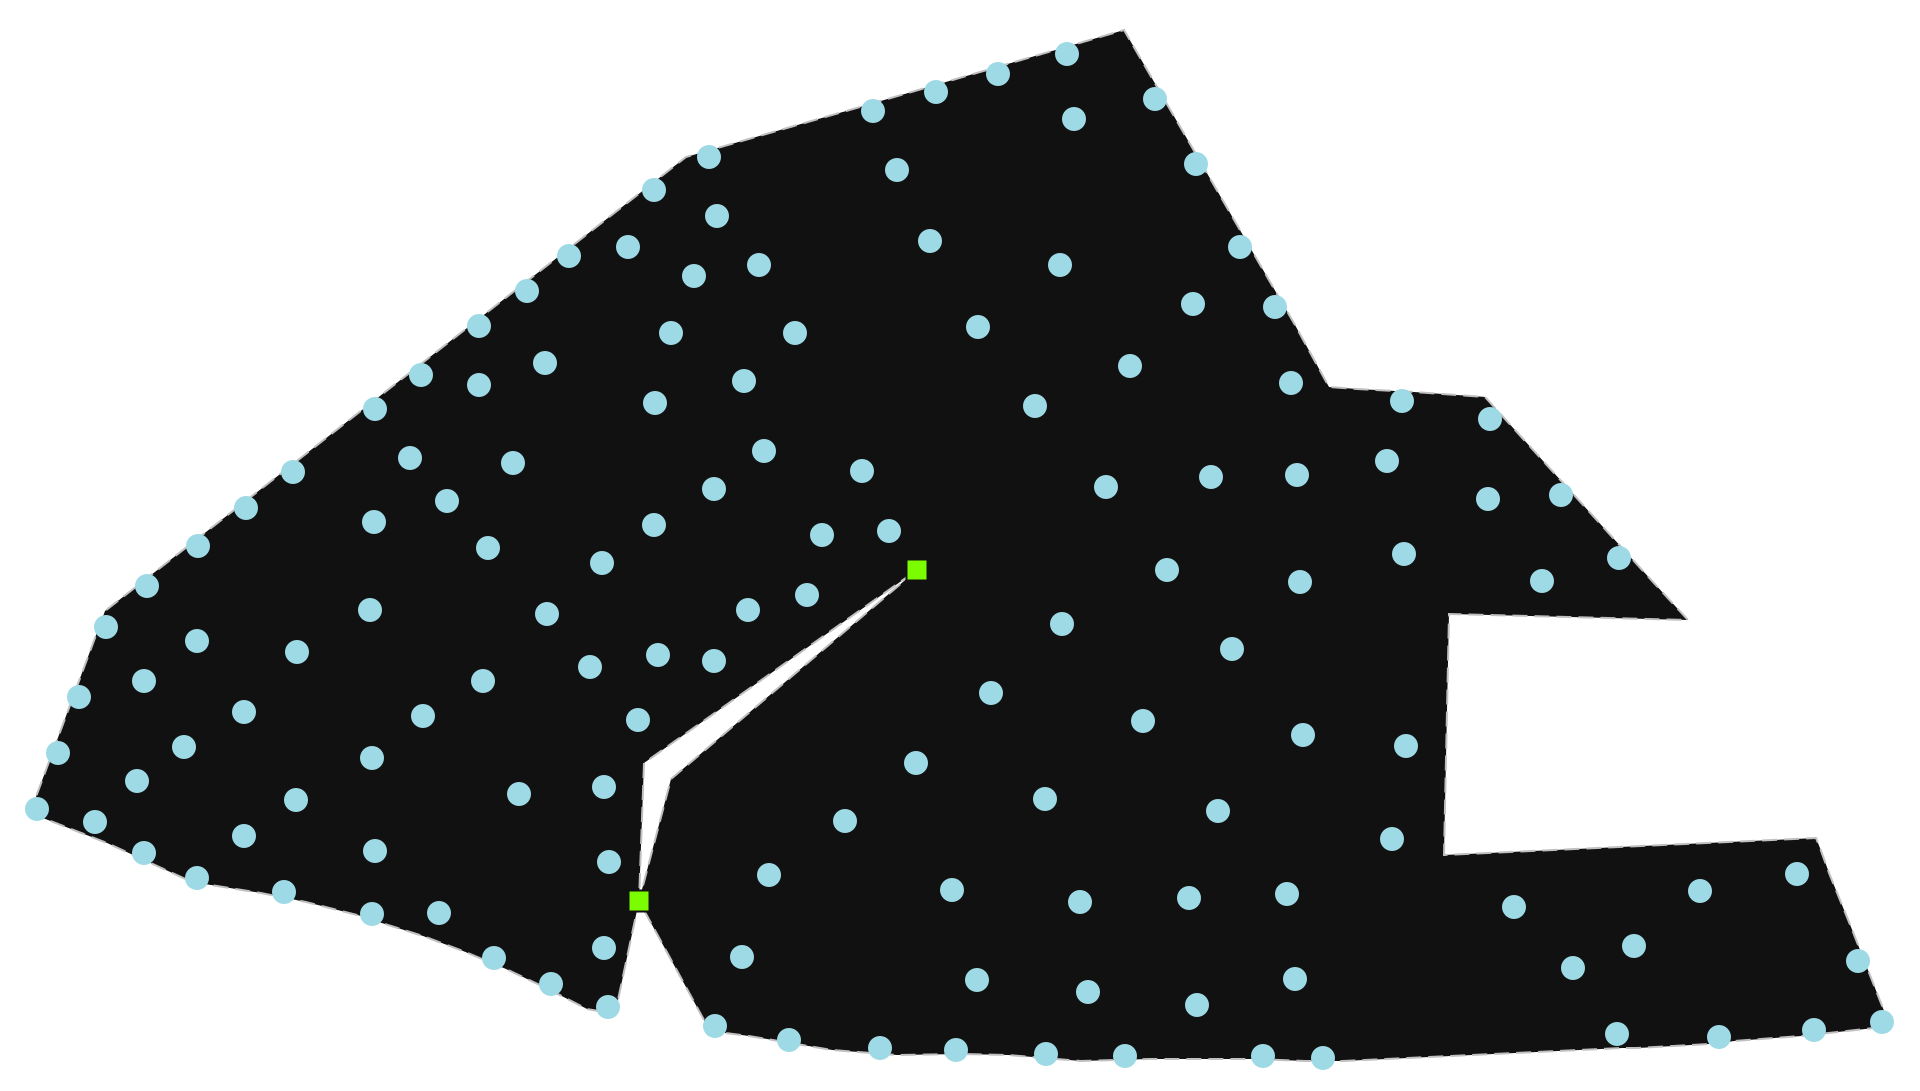

In [3]:
L = locations.kustzuid
svgplot(L)

Optimize Hollandse Kust Zuid

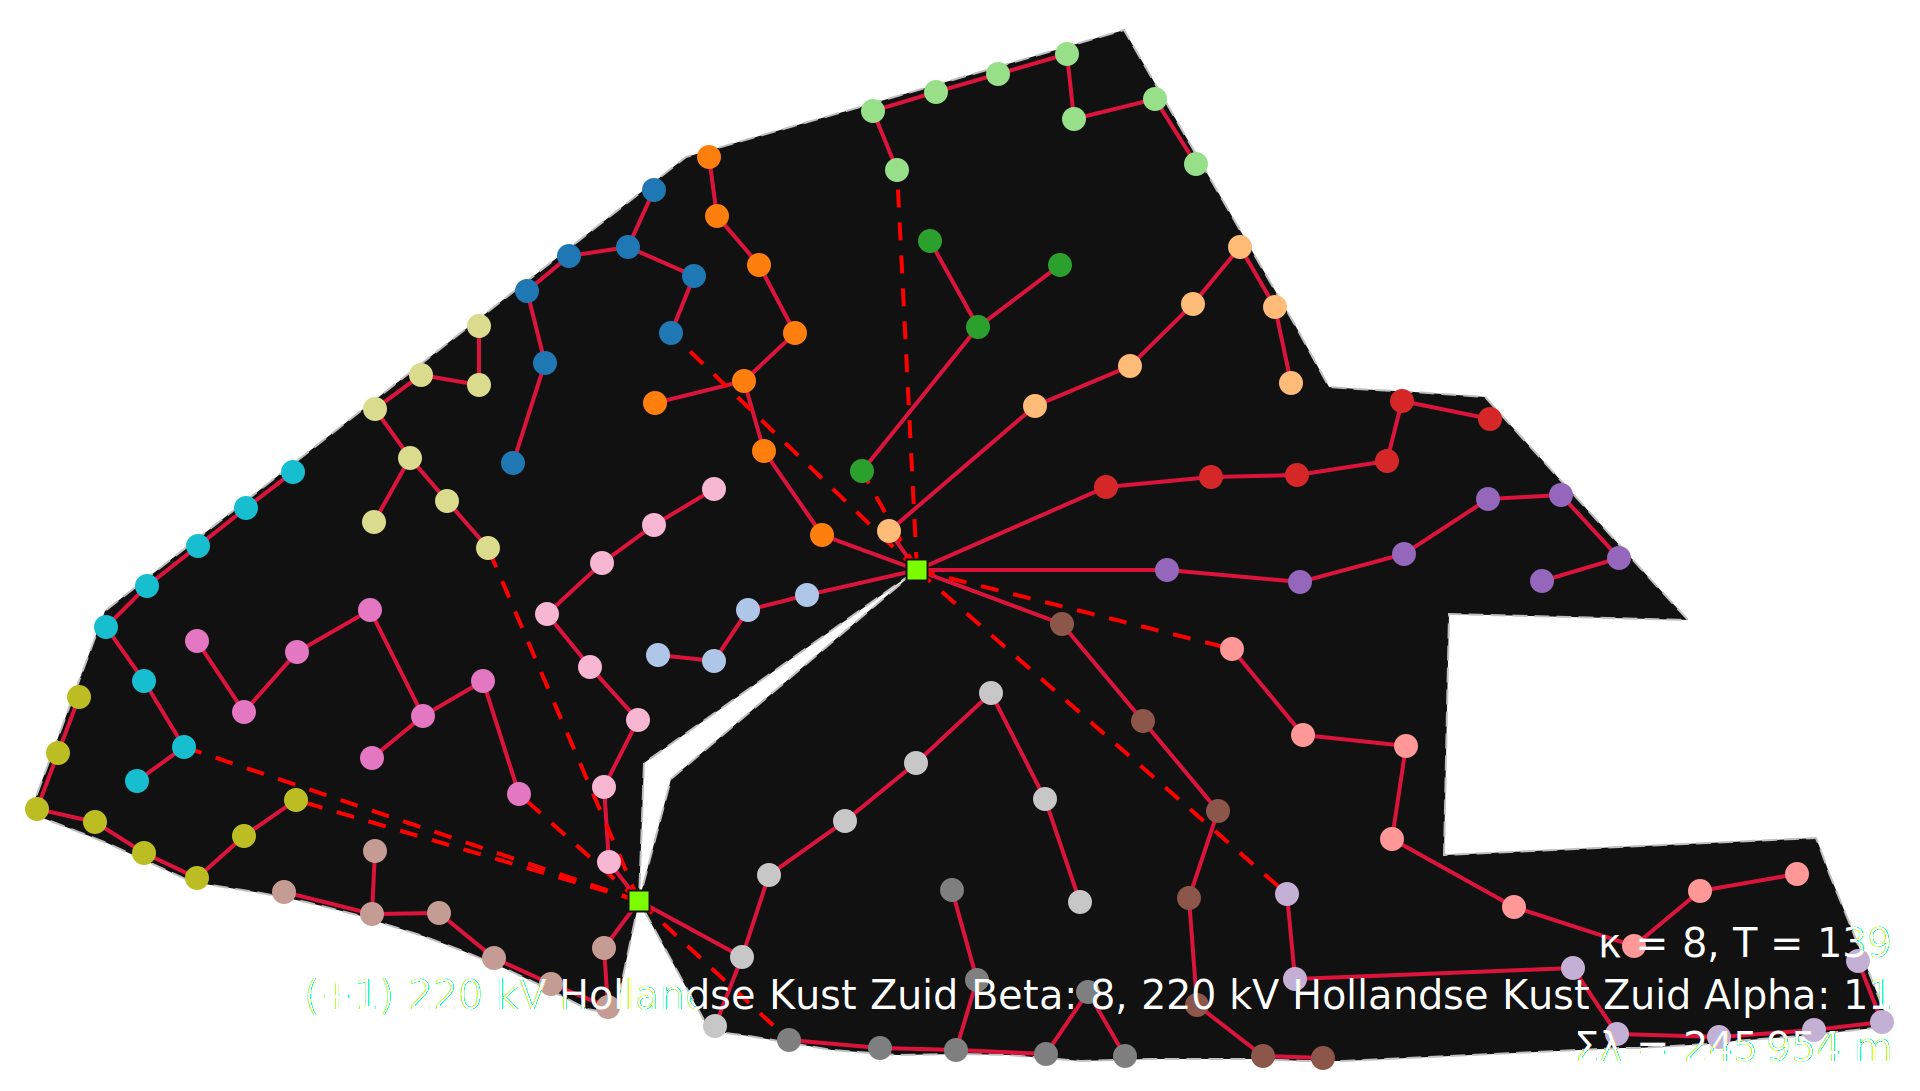

In [4]:
P, A = make_planar_embedding(L)
S = constructor(A, capacity=8)
G_tent = G_from_S(S, A)
svgplot(G_tent)

Route the feeders so as to avoid crossings

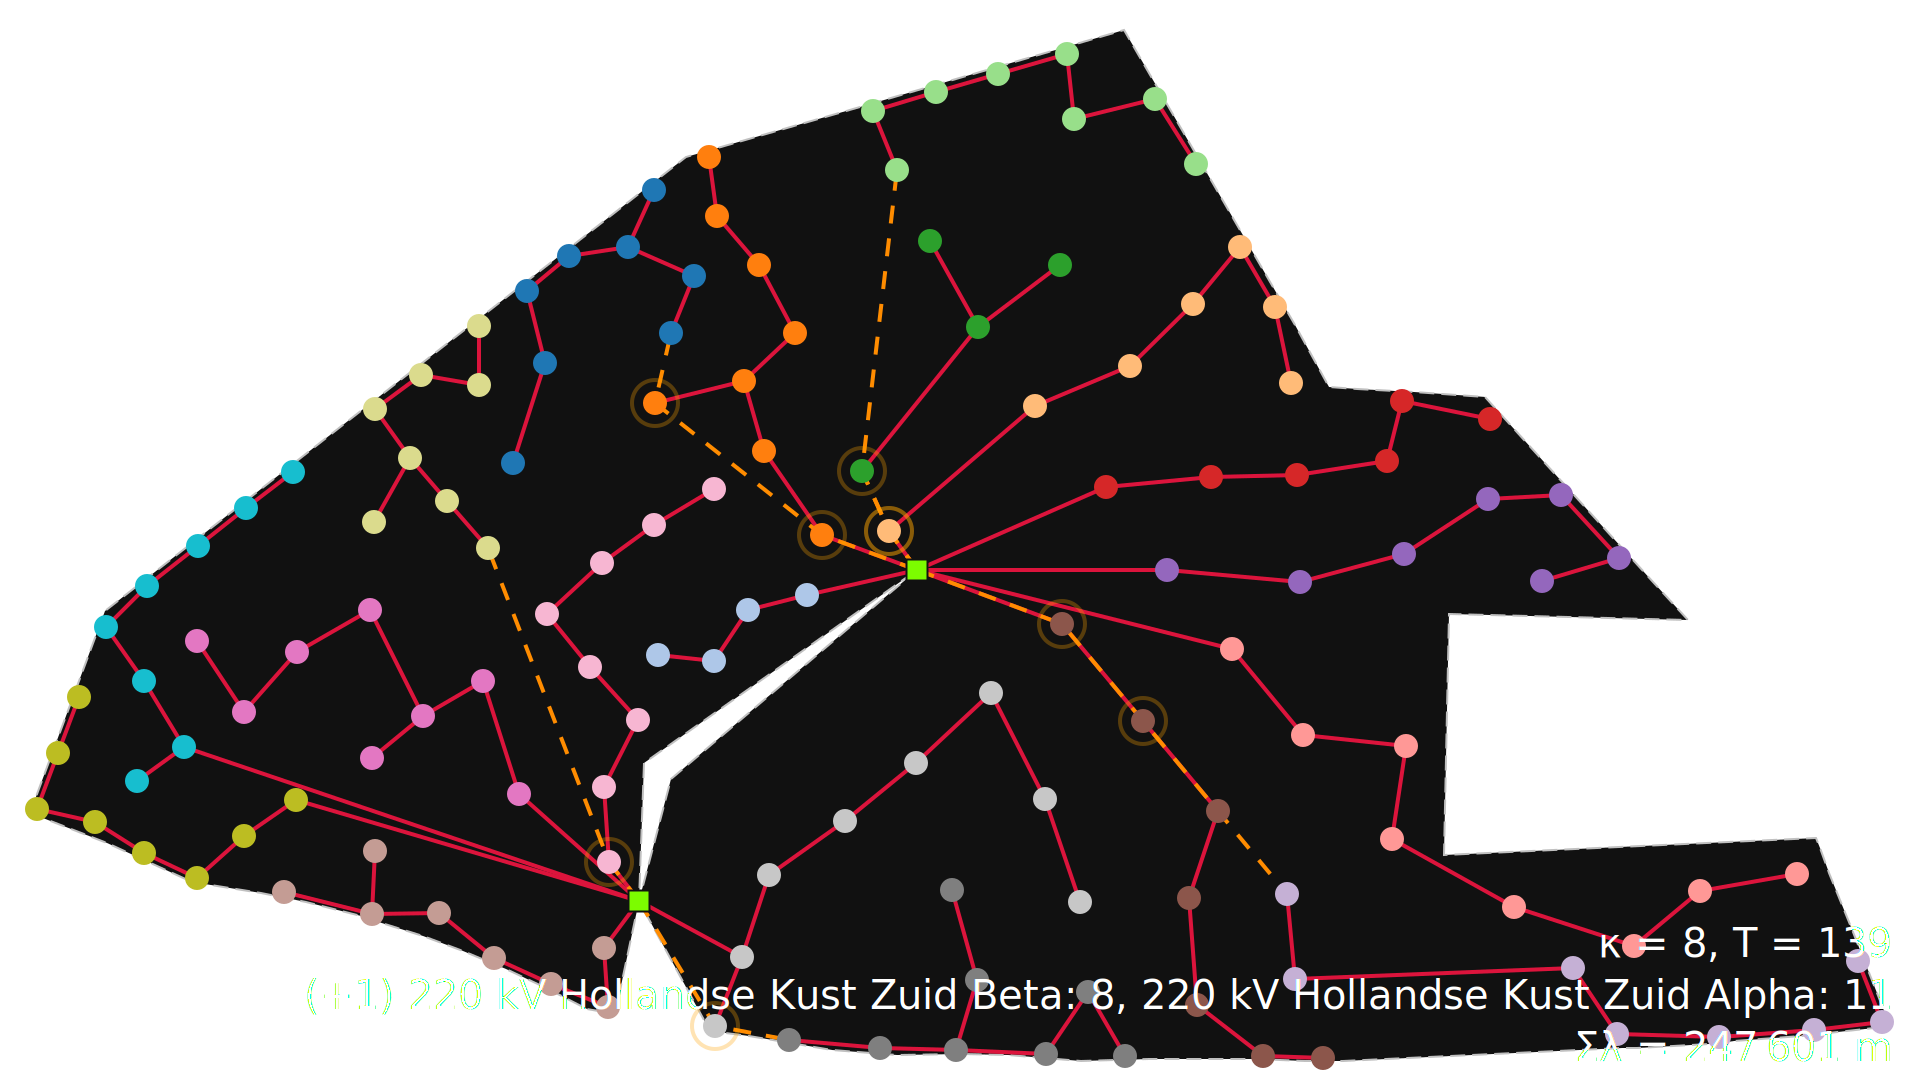

In [5]:
H = PathFinder(G_tent, P, A).create_detours()
svgplot(H)

### Constructor methods and parameters

Load Merkur

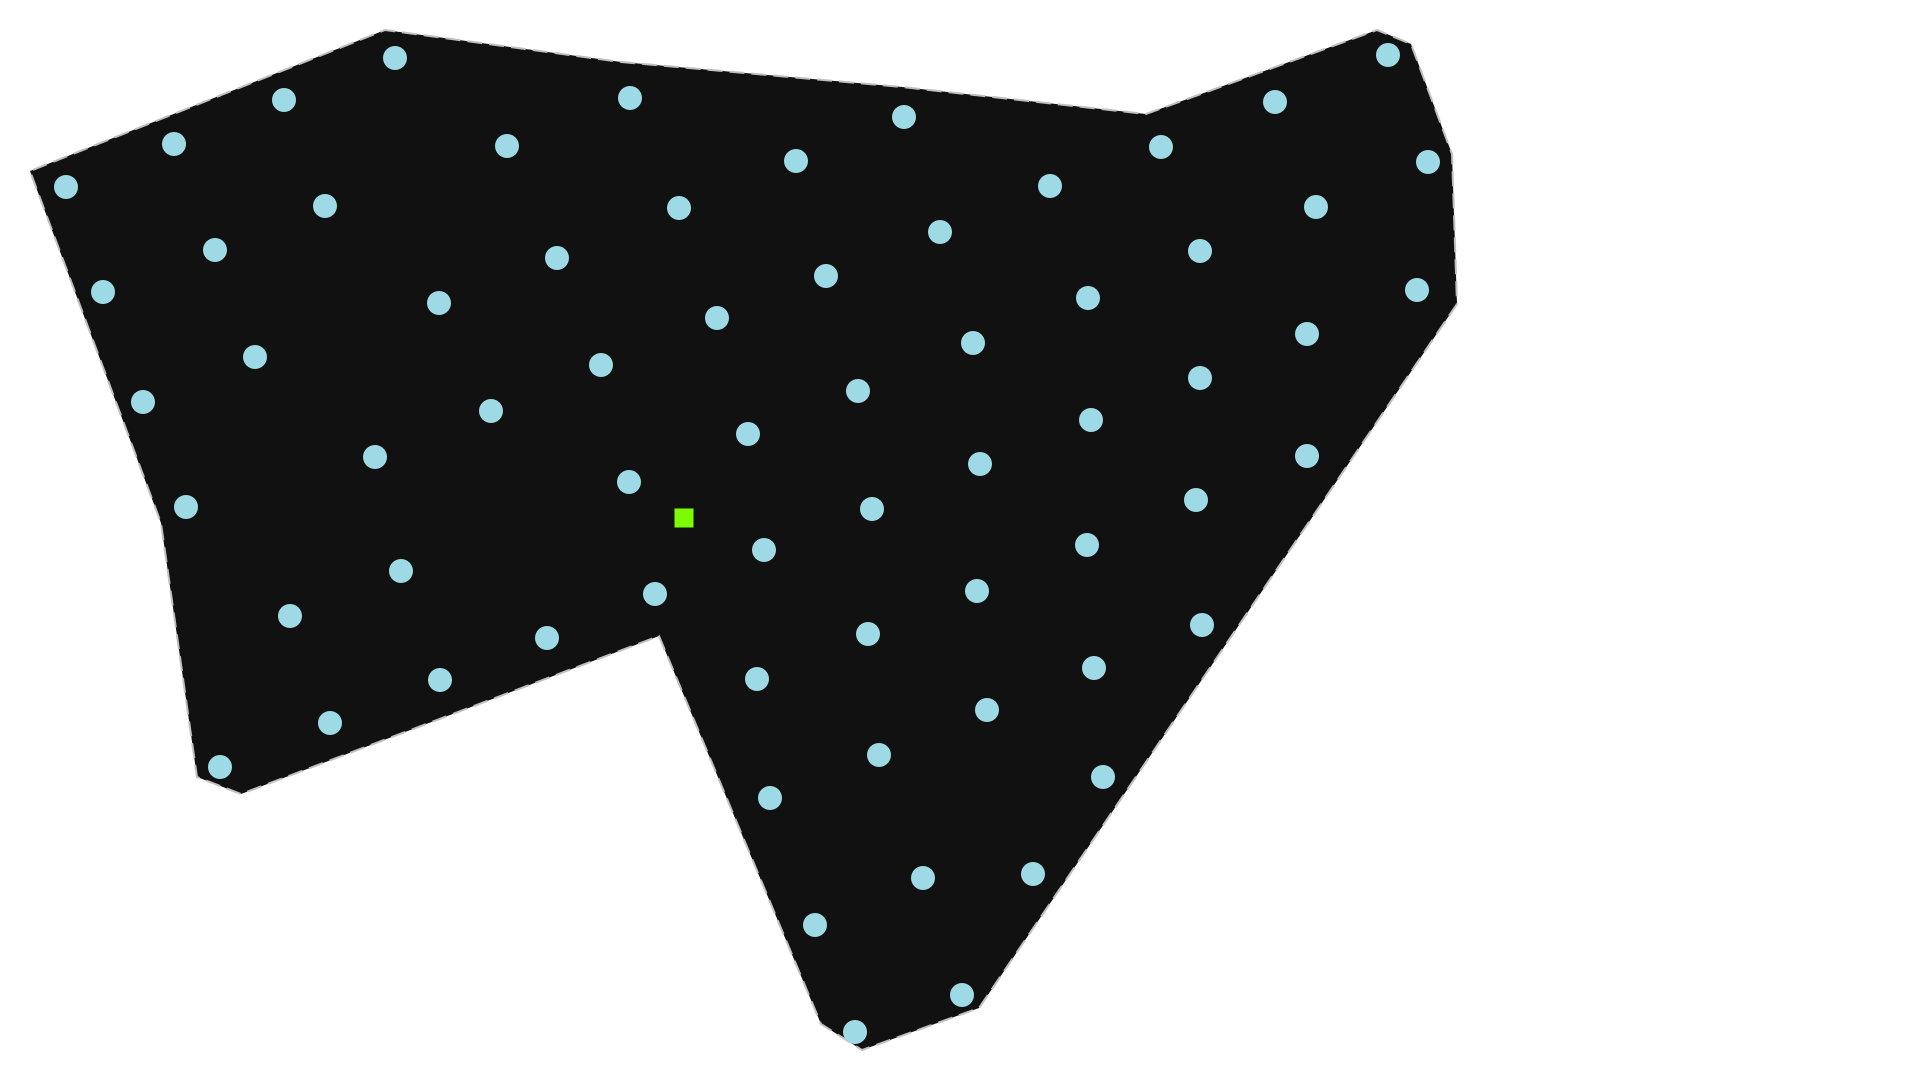

In [6]:
L = locations.merkur
svgplot(L)

Compare solutions obtained with different arguments

In [7]:
P, A = make_planar_embedding(L)
capacity = 9

settings = {
    'default rootlust': {},
    'rootlust (OBEW rootlust style)': dict(
        method='rootlust',
        # matching OBEW's rootlust is capacity-dependent
        rootlust_=(0.0, 0.6 * (capacity - 1) / capacity),  
    ),
    'EW presolver style': dict(
        method='biased_EW',
        weigh_detours=False,
    ),
    'biased_EW (OBEW style)': dict(
        method='biased_EW',
        # straight_feeder_route=False,
        # weigh_detours=True,
    ),
    'straight feeders (CPEW style)': dict(
        method='biased_EW',
        straight_feeder_route=True,
        weigh_detours=False,
    ),
    'radial (NBEW style)': dict(
        method='radial_EW',
        straight_feeder_route=True,
        weigh_detours=False,
    ),
    'radial (segmented feeders)': dict(
        method='radial_EW',
        # straight_feeder_route=False,
        # weigh_detours=True,
    ),
}

In [8]:
solutions = {}
for label, kwargs in settings.items():
    S = constructor(A, capacity=capacity, **kwargs)
    G_tent = G_from_S(S, A)
    G = PathFinder(G_tent, planar=P, A=A).create_detours()
    solutions[label] = G

Visualize the variants

default rootlust


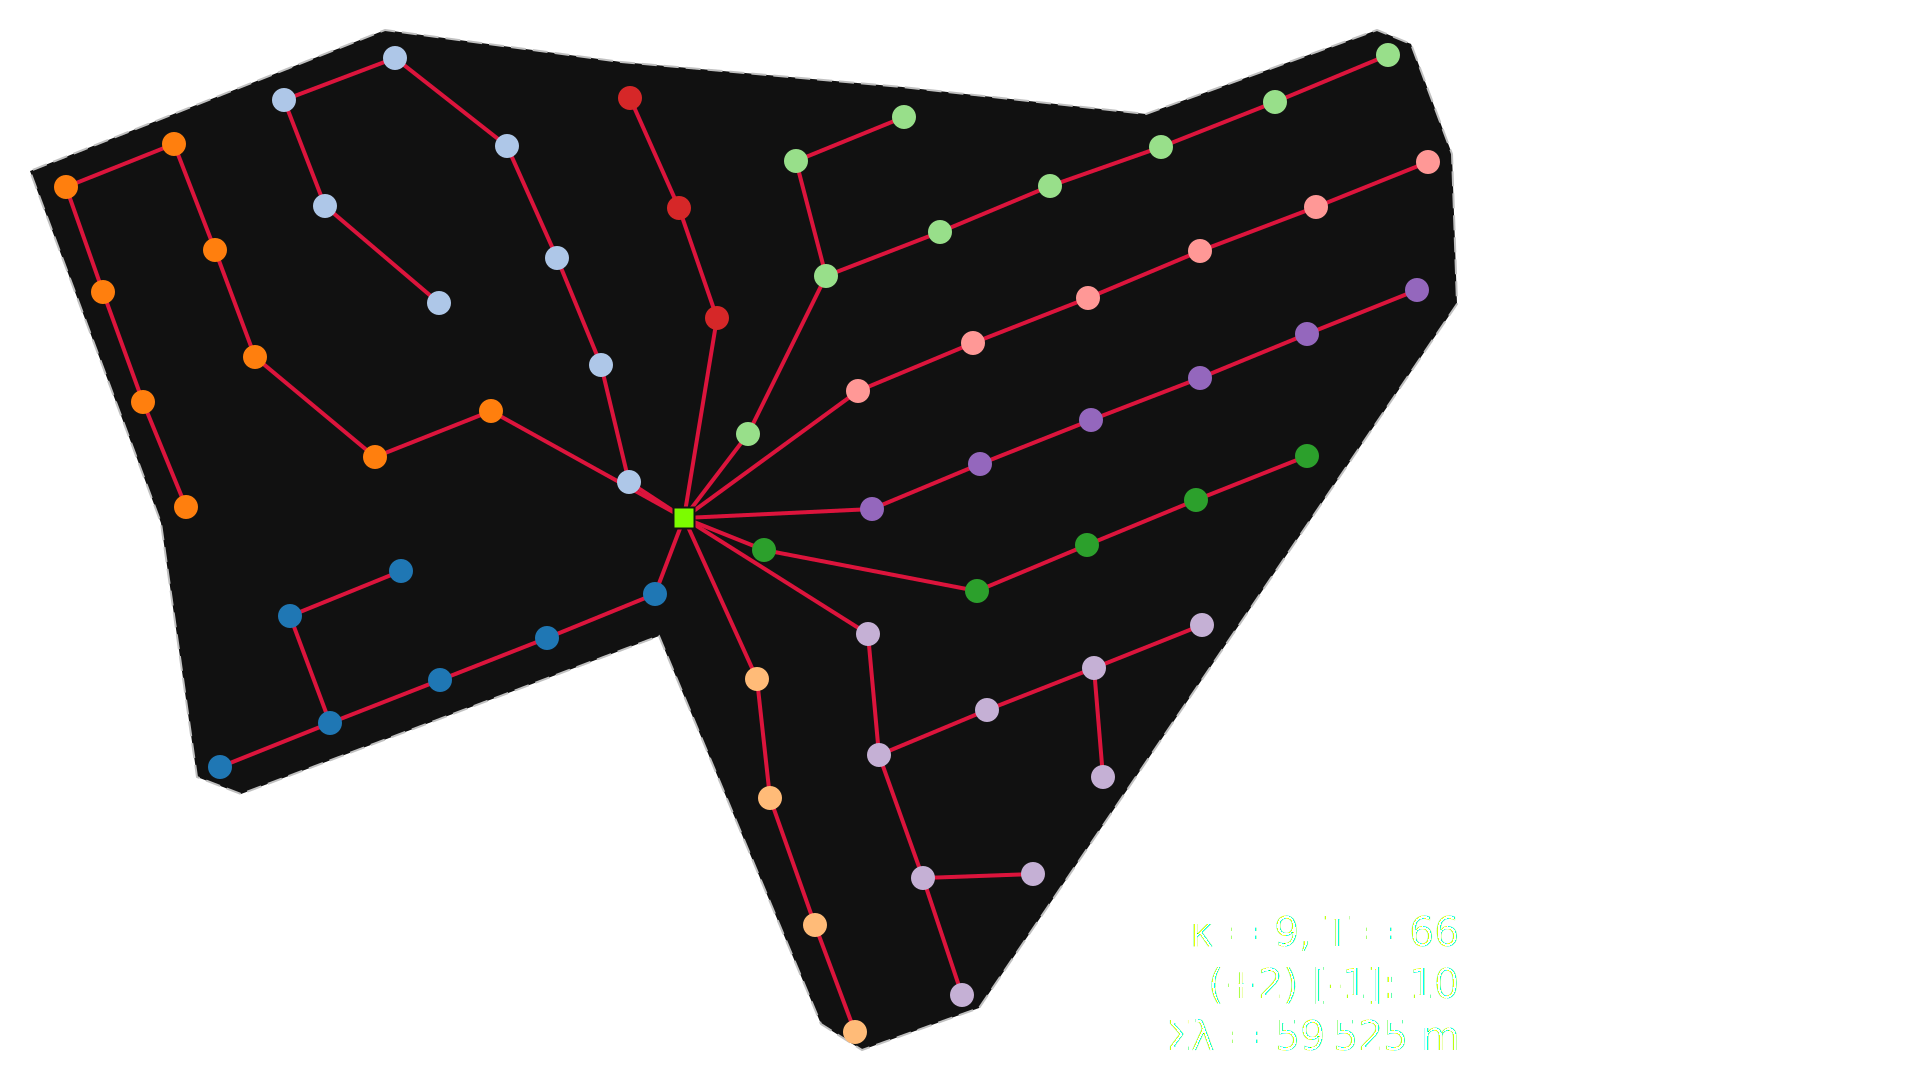

rootlust (OBEW rootlust style)


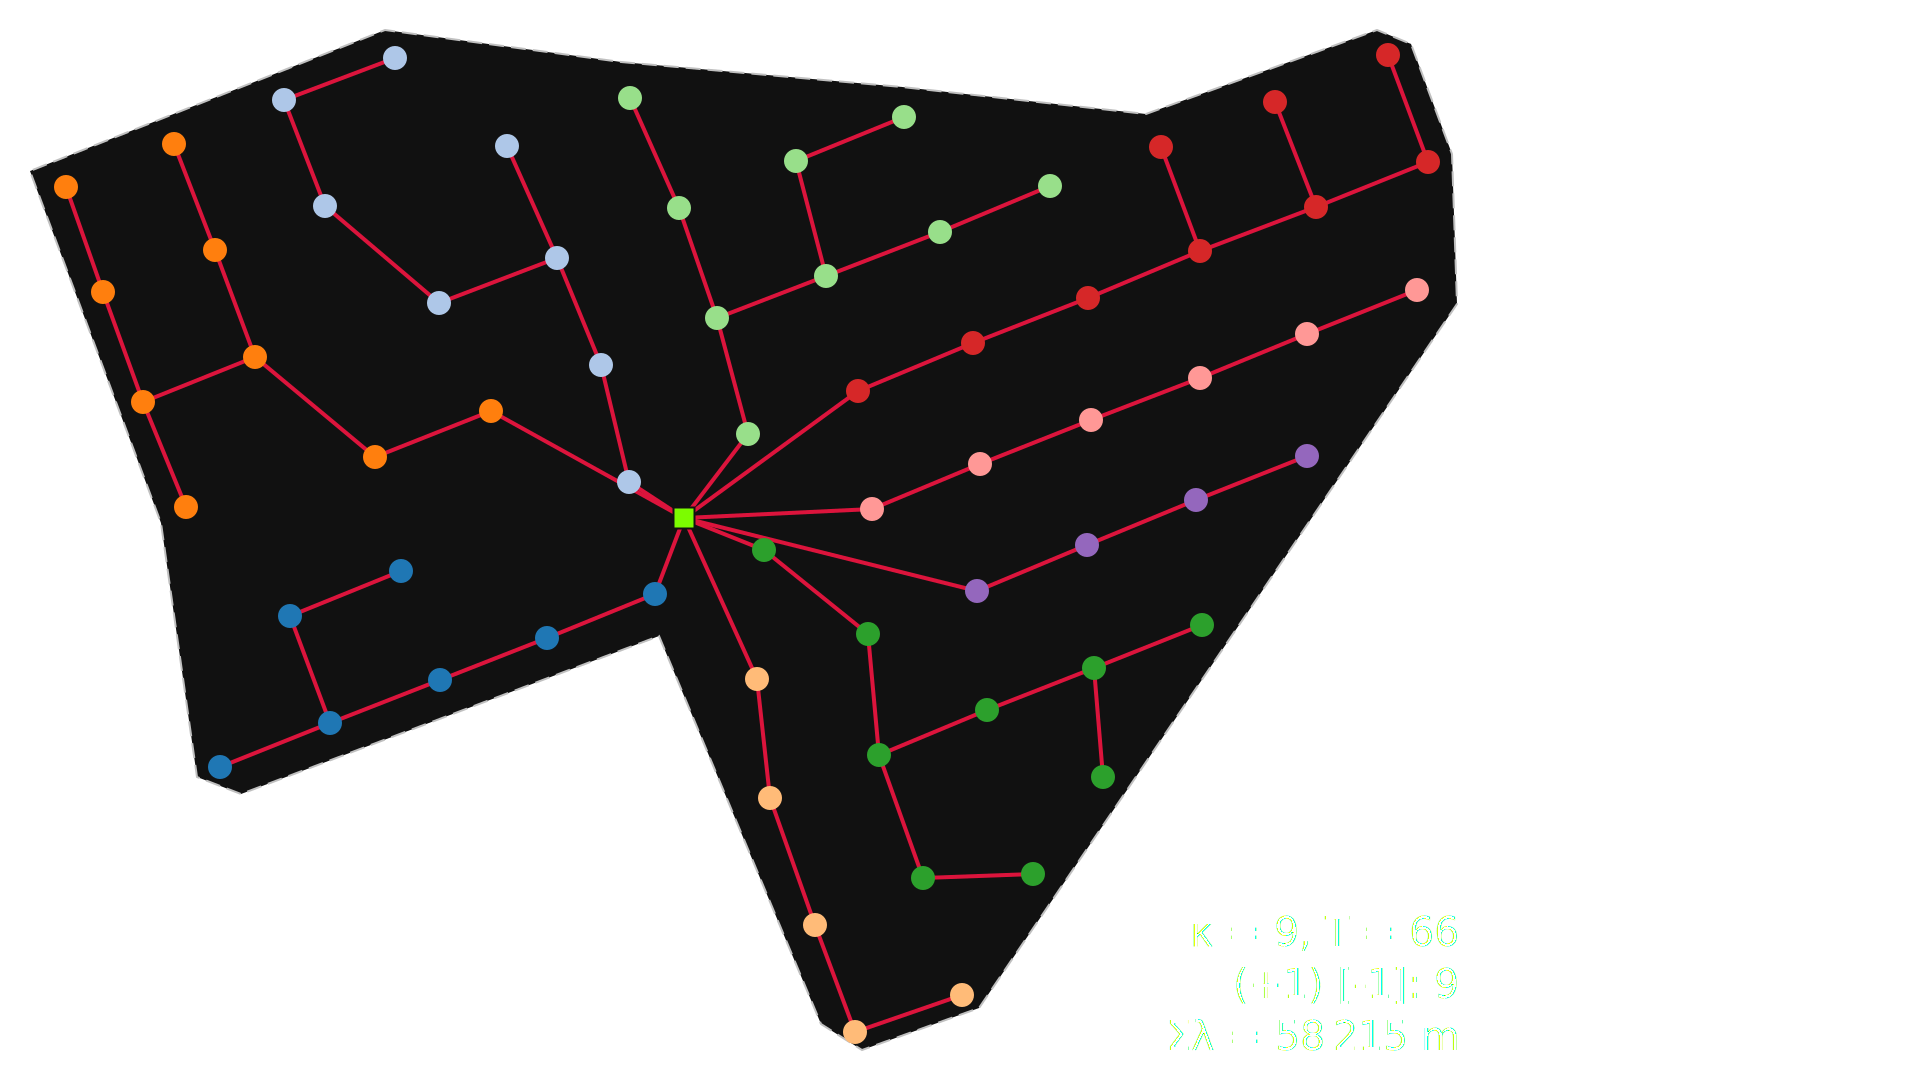

EW presolver style


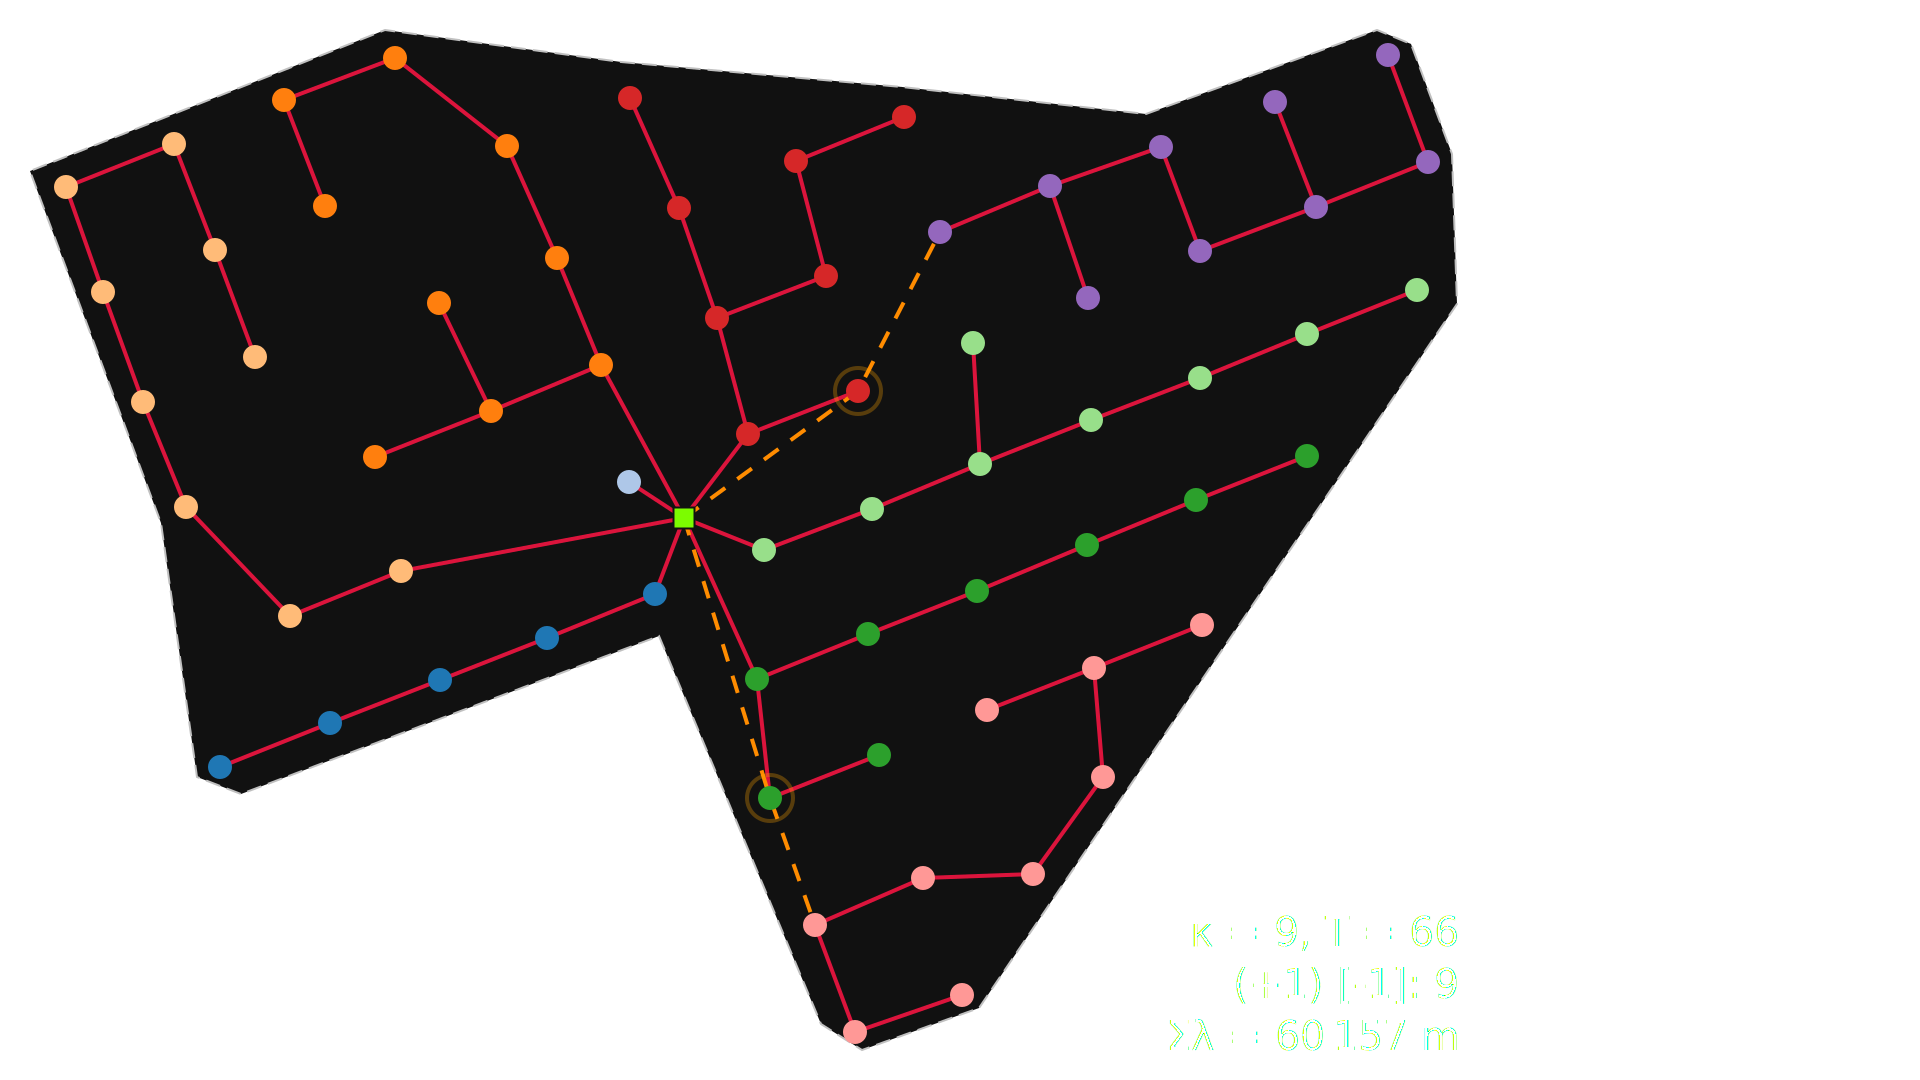

biased_EW (OBEW style)


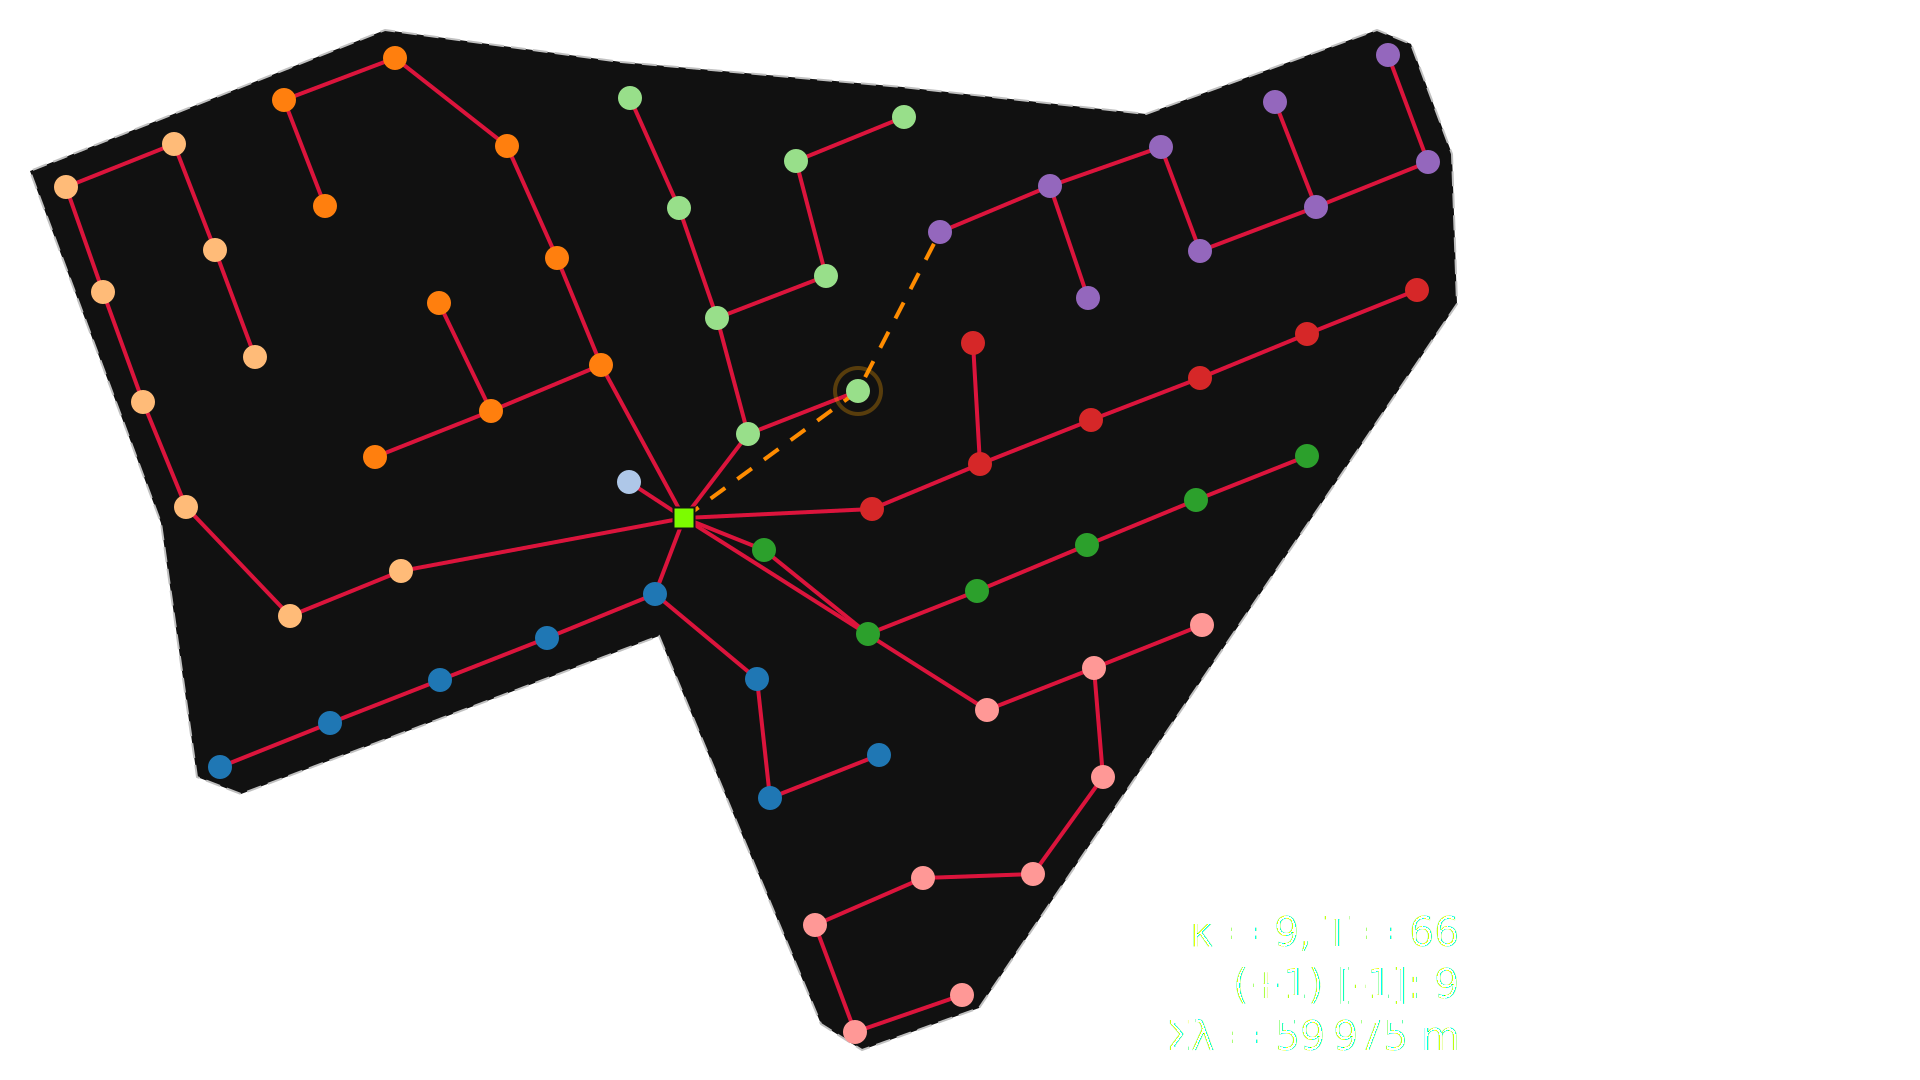

straight feeders (CPEW style)


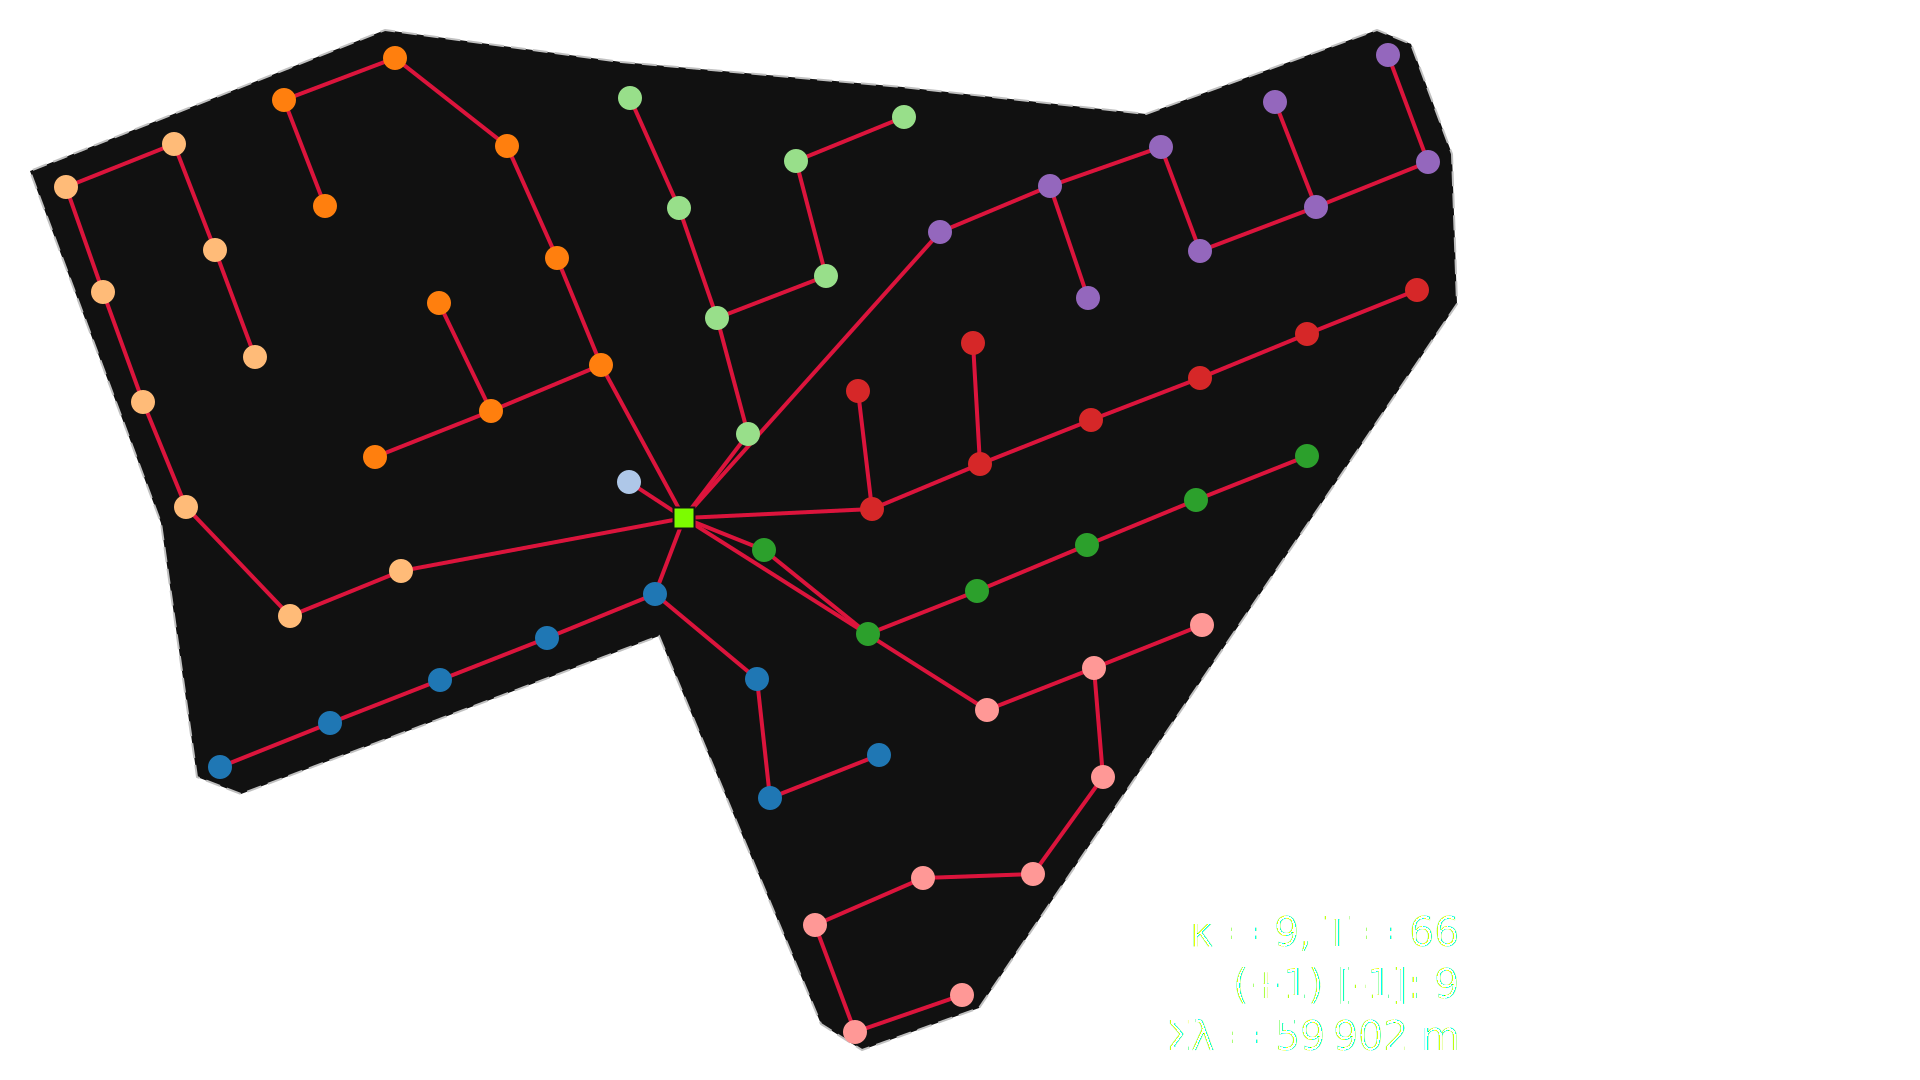

radial (NBEW style)


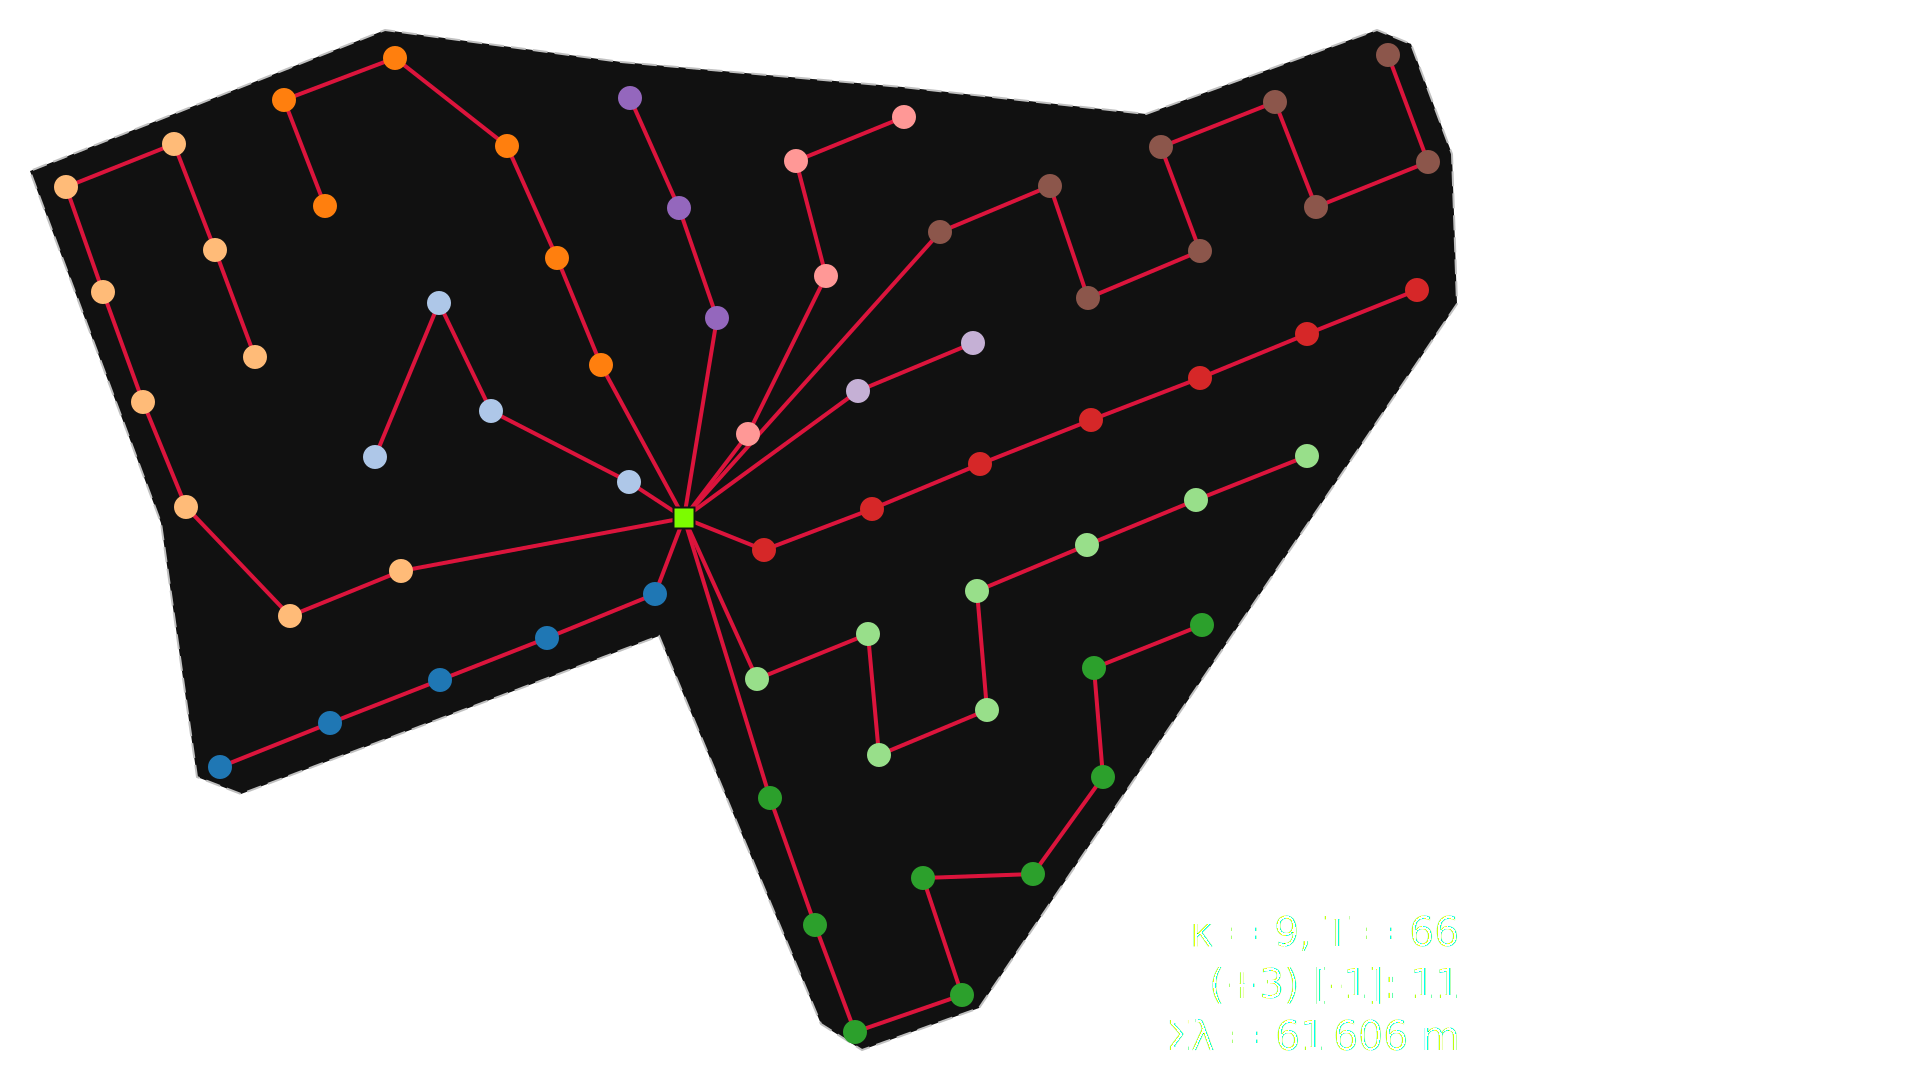

radial (segmented feeders)


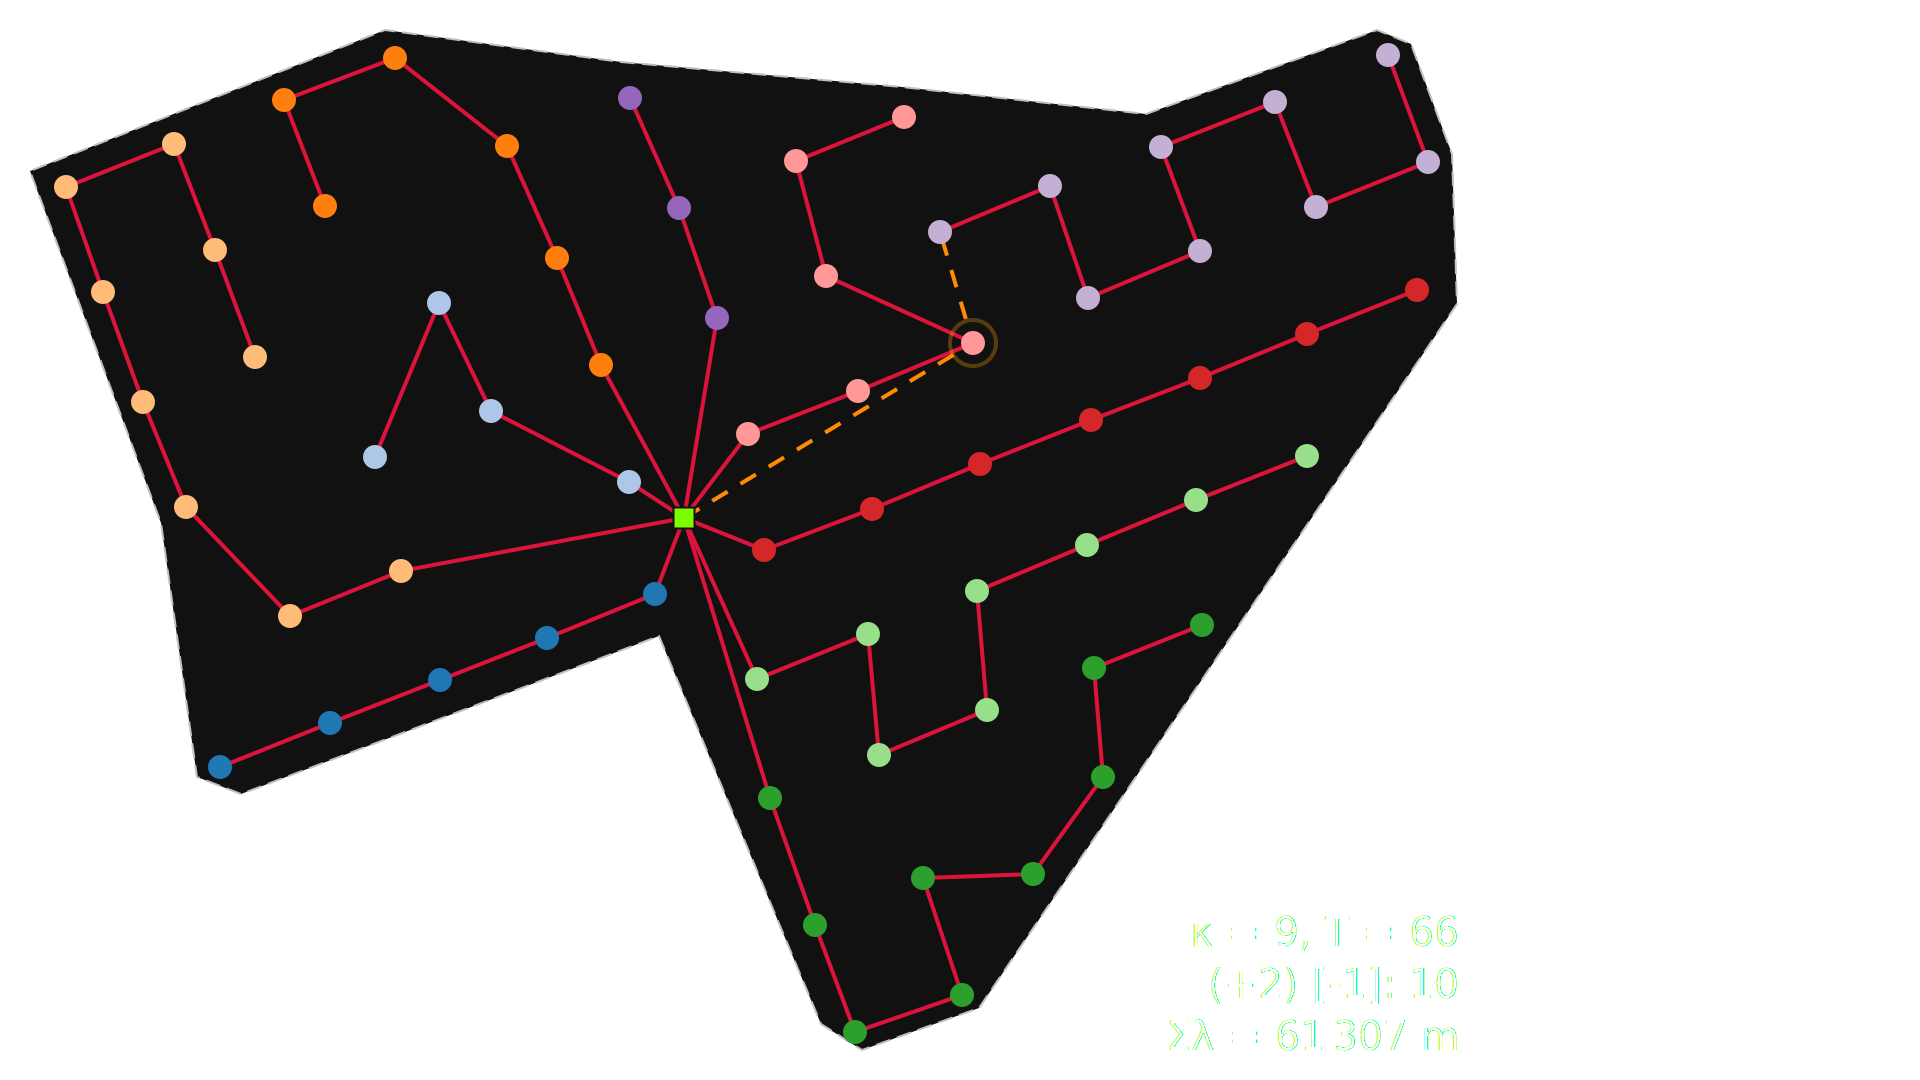

In [9]:
for label, G in solutions.items():
    print(label)
    display(svgplot(G))